In [1]:
from seaborn import *
from pylab   import *

### Copying parameters from problem statement

In [2]:
Rm = 10      # MΩ membrane resistance
Cm = 2       # nF membrane capacitance
τm = Rm*Cm   # ms membrane time constant
El = -70     # mV leak reversal potential
Vr = -80     # mV reset voltage
Vt = -54     # mV threshold voltage
I  = 1.8     # nA applied current
P  = 0.5     # (abstract units) synapse increment
τs = 10      # ms synaptic time constant
gs = 0.15/Rm # seimens, synapse maximal conductance
Δt = 0.1     # ms
# Simulation parameters
T  = 1.0     # seconds
N  = int(round(T*1000/Δt))
αs = exp(-Δt/τs) # Synapse decay for fixed step
K  = 2
W  = 1-eye(K)

### Simulation loop

In [3]:
# mV synapse reversal potential (try also -80)
Es = -80
# Rasters to hold voltages, spikes, syanpse state
v,y,s = zeros((3,N+1,K))
# Initial voltages
v[0,:] = uniform(Vr,Vt,K)
for i in range(1,N+1):
    # Forward Euler for the voltage
    v[i] = v[i-1] + ( El-v[i-1] + I*Rm + (Es-v[i-1])*(gs*Rm*s[i-1]) )*(Δt/τm)
    # Exponential Euler on the synapse (simpler)
    s[i] = s[i-1]*αs
    # Test for voltages crossing threshold
    y[i] = v[i]>Vt
    # If spiked, reset voltage and propagate spikes to downstream synapses
    v[i]+= y[i]*(Vr-v[i])
    s[i]+= P*W@y[i]

## Plot 

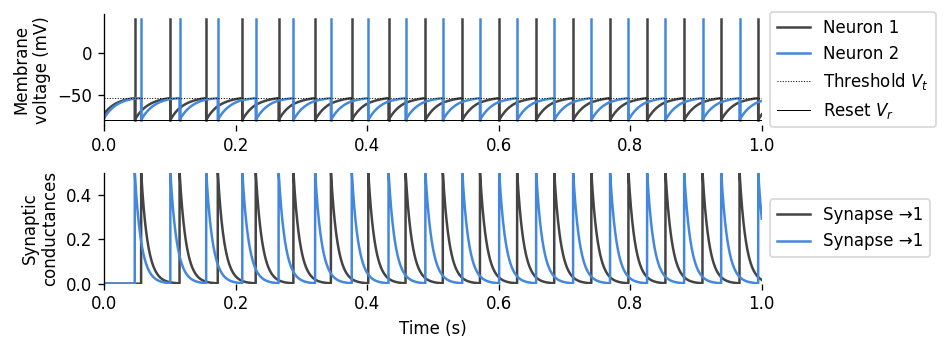

In [4]:
Vs = 40 # fake spike voltage
c = ['#444','#48d','#284','#c82','#86c']
figure(0,(8,3),120)
subplot(211)
tt = arange(N+1)*Δt/1000
for k in range(K):
    plot(tt,v[:,k],label='Neuron %d'%(k+1),color=c[k])
    for t in where(y[:,k])[0]*(Δt/1000):
        plot([t,t],[Vs,Vr],color=c[k])
despine(bottom=True)
axhline(Vt,color='k',lw=0.6,linestyle=':',label='Threshold $V_t$')
axhline(Vr,color='k',lw=0.6,linestyle='-',label='Reset $V_r$')
legend(bbox_to_anchor=(1.0,0.5),loc='center left')
xlim(0,T)
ylabel("Membrane\nvoltage (mV)")
subplot(212)
for k in range(K):
    plot(tt,s[:,k],label='Synapse →1',color=c[k])
despine(bottom=True)
legend(bbox_to_anchor=(1.0,0.5),loc='center left')
xlim(0,T)
ylim(0,0.5)
xlabel("Time (s)")
ylabel("Synaptic\nconductances")
tight_layout()

# Demo Instructions: 

1. Explore setting $E_s$ in the range between -80 and 0 mV, the (approximate) reversal potentials for GABA-gated GABA-A receptors and glutamate-gated AMPA receptros, respectively. You should see qualitatively different behaviours at these two extremes. What does the system do as it transitions?
2. Explore the program's structure. Try increasing the number of neurons, or adjusting other paramters. What behaviours do you see? 